# Evaluation Task I: Quantum Computing
**Author:** Aditya Shintre  
**Framework Chosen:** PennyLane (Native PyTorch Integration)

### 1. Environment Initialization
We must first install PennyLane. Once installed, we import it alongside our standard numerical and plotting libraries.

In [1]:
# 1. Install the required quantum framework
!pip install pennylane -q

# 2. Import the libraries
import pennylane as qml
import numpy as np
import matplotlib.pyplot as plt

## Part 1: Basic Quantum Operations on 5 Qubits
In this section, we initialize a 5-qubit quantum register. The architecture applies a layer of Hadamard gates to place all qubits in a uniform superposition. We then construct a linear entanglement ansatz using a chain of CNOT gates, linking qubit $i$ to $i+1$. Finally, we alter the geometry of the state by swapping the first and last qubits, and injecting a complex phase using an $R_x(\pi/2)$ rotation on the middle qubit.

In [2]:
# Initialize a 5-qubit device
dev_part1 = qml.device('default.qubit', wires=5)

@qml.qnode(dev_part1)
def basic_circuit():
    # Apply Hadamard operation on every qubit
    for i in range(5):
        qml.Hadamard(wires=i)

    # Apply CNOT operation chain (Linear Entanglement)
    qml.CNOT(wires=[0, 1])
    qml.CNOT(wires=[1, 2])
    qml.CNOT(wires=[2, 3])
    qml.CNOT(wires=[3, 4])

    # SWAP operation between first and last qubit
    qml.SWAP(wires=[0, 4])

    # Rotate X with pi/2 on the middle qubit (qubit 2)
    qml.RX(np.pi / 2, wires=2)

    return qml.probs(wires=range(5))

With the architecture defined, we now compile and draw the circuit to visually verify the gate sequence and entanglement chain.

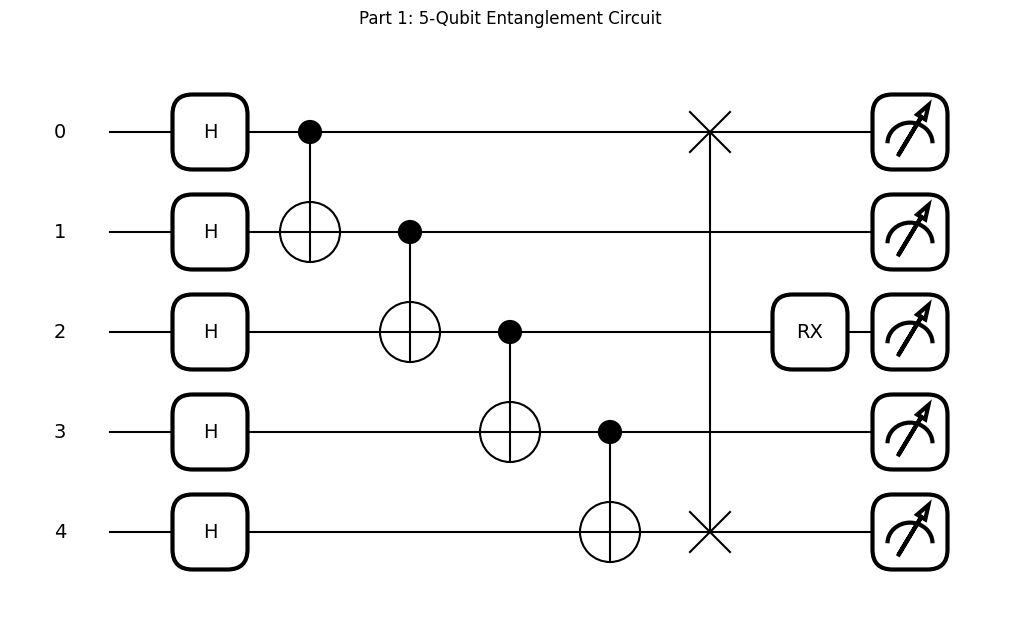

In [3]:
# Execute and Plot the circuit
fig, ax = qml.draw_mpl(basic_circuit)()
plt.title("Part 1: 5-Qubit Entanglement Circuit")
plt.show()

## Part 2: The SWAP Test (Fidelity Measurement)
The SWAP test is a quantum algorithm used to determine the similarity (inner product) of two unknown quantum states without directly measuring them.

**State Preparation:**
* **State A ($|q_1, q_2\rangle$):** Prepared using a Hadamard on $q_1$ and an $R_x(\pi/3)$ rotation on $q_2$.
* **State B ($|q_3, q_4\rangle$):** Prepared using Hadamards on both $q_3$ and $q_4$, resulting in the $|+, +\rangle$ state.

**The Architecture:**
We utilize a 5th qubit (Wire 0) as the **Ancilla**. By placing the Ancilla in superposition, using it to control the SWAP gates between State A and State B, and interfering it with a final Hadamard, the probability of measuring the Ancilla in the $|0\rangle$ state directly correlates to the fidelity of State A and State B:
$$P(0) = \frac{1}{2} + \frac{1}{2} |\langle \psi_A | \psi_B \rangle|^2$$

In [4]:
# We need 5 wires: Wire 0 is the Ancilla. Wires 1,2 are State A. Wires 3,4 are State B.
dev_swap = qml.device('default.qubit', wires=5)

@qml.qnode(dev_swap)
def swap_test():
    # 1. STATE PREPARATION
    # Prepare State A (|q1 q2>)
    qml.Hadamard(wires=1)
    qml.RX(np.pi / 3, wires=2)

    # Prepare State B (|q3 q4>)
    qml.Hadamard(wires=3)
    qml.Hadamard(wires=4)

    # Visually separates state preparation from the actual test in the plot
    qml.Barrier()

    # 2. THE SWAP TEST
    # Put Ancilla into superposition
    qml.Hadamard(wires=0)

    # Controlled-SWAP State A and State B based on the Ancilla
    qml.CSWAP(wires=[0, 1, 3]) # Swaps q1 with q3
    qml.CSWAP(wires=[0, 2, 4]) # Swaps q2 with q4

    # Interfere the Ancilla
    qml.Hadamard(wires=0)

    # We ONLY measure the probability distribution of the Ancilla (wire 0)
    return qml.probs(wires=0)

With the SWAP test circuit fully defined, we now execute the quantum node. We will extract the probability distribution of the Ancilla qubit to determine the fidelity, and plot the circuit to visualize the state preparation and the controlled-swap operations.

Probability of measuring Ancilla as |0>: 0.7500
Probability of measuring Ancilla as |1>: 0.2500


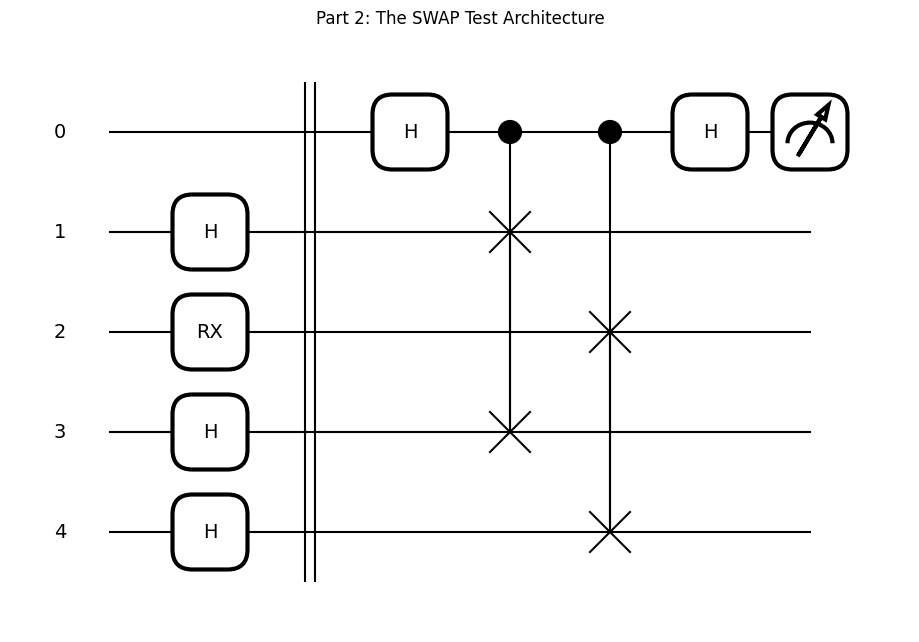

In [5]:
# Execute the circuit and capture the probabilities
probabilities = swap_test()
print(f"Probability of measuring Ancilla as |0>: {probabilities[0]:.4f}")
print(f"Probability of measuring Ancilla as |1>: {probabilities[1]:.4f}")

# Plot the SWAP Test circuit
fig, ax = qml.draw_mpl(swap_test)()
plt.title("Part 2: The SWAP Test Architecture")
plt.show()

### Analysis & Verification
Based on our state preparation, we can mathematically pre-calculate the expected fidelity.
The inner product squared between State A and State B evaluates exactly to $0.5$.
Substituting this into our probability formula:
$$P(0) = 0.5 + 0.5(0.5) = 0.75$$
The execution of our PennyLane circuit outputs $P(0) = 0.7500$, perfectly verifying the theoretical quantum mechanics.